In [1]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import imageio
import pydicom
import SimpleITK as sitk

In [2]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_nib(file_path: str):
    nii_data = nib.load(file_path)

    image_data = nii_data.get_fdata()
    return image_data

def save_nib(file_path: str, volume):
    ct_image = sitk.GetImageFromArray(volume)
    sitk.WriteImage(ct_image, file_path)

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis

def numpy_to_gif(array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exists_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}_x.gif"
    # save_path_y = f"{folder_path}/{case_name}_y.gif"
    # save_path_z = f"{folder_path}/{case_name}_z.gif"
    print(save_path_x)
    frames_x = []
    # frames_y = []
    # frames_z = []
    
    for i in range(array.shape[0]):
        img_x = Image.fromarray(scale_image(array[i, :, :])) 
        frames_x.append(img_x)
        # img_y = Image.fromarray(scale_image(array[:, i, :])) 
        # frames_y.append(img_y)
        # img_z = Image.fromarray(scale_image(array[:, :, i])) 
        # frames_z.append(img_z)

    frames_x[0].save(save_path_x, save_all=True, append_images=frames_x[1:], duration=duration, loop=0)
    # frames_y[0].save(save_path_y, save_all=True, append_images=frames_y[1:], duration=duration, loop=0)
    # frames_z[0].save(save_path_z, save_all=True, append_images=frames_z[1:], duration=duration, loop=0)
    
def lung_window_clip_volume(pixel_array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = []
    for arr in pixel_array:
        clipped = arr.copy()
        clipped[clipped > max_px] = max_px
        clipped[clipped < min_px] = min_px
        clipped_array.append(clipped)
        
    return np.stack(clipped_array, axis = 0)


In [12]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-0434/0434_NI001.npy"
pixel_array = load_npy(file_path)
print("Volume shape:", pixel_array.shape)
print("Max pixel:", pixel_array.max())
print("Min pixel:", pixel_array.min())

clipped_array = lung_window_clip_volume(pixel_array)
print("Clipped shape:", clipped_array.shape)
print("Clipped pixel:", clipped_array.max())
print("Clipped pixel:", clipped_array.min())

Volume shape: (128, 512, 512)
Max pixel: 2395
Min pixel: -3024
Clipped shape: (128, 512, 512)
Clipped pixel: 800
Clipped pixel: -1200


In [ ]:
# Convert 3D volume to LIDC Gif
numpy_to_gif(pixel_array, case_name="404_HU")

# Convert 3D clipped volume to LIDC Gif
numpy_to_gif(clipped_array, case_name="404_HU_clipped")


/data/hpc/dqm/3D-SegClass-Medical/assets/image/404_HU_x.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/image/404_HU_clipped_x.gif


In [5]:
file_path = "/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-0434/0434_MA001.npy"
pixel_array = load_npy(file_path)
print("Volume shape:", pixel_array.shape)
print("Max pixel:", pixel_array.max())
print("Min pixel:", pixel_array.min())

# Convert 3D mask
numpy_to_gif(pixel_array * 255, case_name="404_HU", folder_name="mask")

Volume shape: (128, 512, 512)
Max pixel: 1
Min pixel: 0
/data/hpc/dqm/3D-SegClass-Medical/assets/mask/404_HU_x.gif


1057
-2048


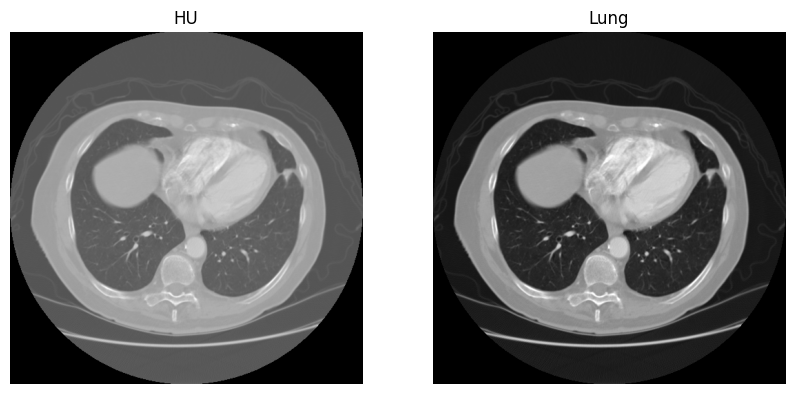

In [ ]:
array_HU = pixel_array[55, :, :]
print(array_HU.max())
print(array_HU.min())
array_Lung = normalize_image(lung_window_clip(array_HU))

plot_images(array_HU, array_Lung)

LIDC: 1209
LIDC: -2048
Max pixel: 1209.0
Min pixel: -2048.0
Max pixel: 2233
Min pixel: -1024


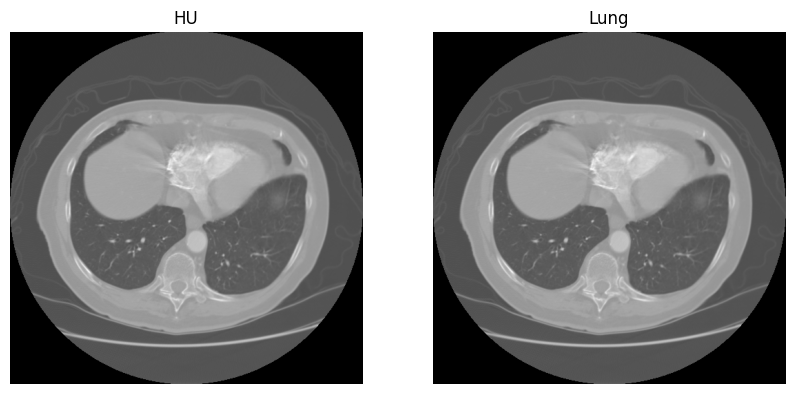

In [12]:
dicom = load_dcom('/data/hpc/dqm/data/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-078.dcm')

arr_dcom = dicom.pixel_array * dicom.RescaleSlope + dicom.RescaleIntercept

# arr_dcom_lung = normalize_image(lung_window_clip(arr_dcom))
print("LIDC:", pixel_array[50, :, :].max())
print("LIDC:", pixel_array[50, :, :].min())

print("Max pixel:", arr_dcom.max())
print("Min pixel:", arr_dcom.min())

print("Max pixel:", dicom.pixel_array.max())
print("Min pixel:", dicom.pixel_array.min())

plot_images(pixel_array[50, :, :], dicom.pixel_array)

In [62]:
test = pixel_array[:, :, 50] + 1024 - dicom.pixel_array
print(test.sum())

2051600


In [23]:
print(arr_dcom.max())
print(arr_dcom.min())

3071.0
-2048.0


In [30]:
print(dicom.pixel_array.max())
print(dicom.pixel_array.min())

4095
-1024


In [28]:

print(pixel_array.max())
print(pixel_array.min())

2047.0
-3072.0
